In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

# Sentiment140 Dataset

In [4]:
sentiment140_path = "../data/sentiment140_dataset.csv"

df_social = pd.read_csv(sentiment140_path, encoding='latin-1', header=None)
df_social.head(10)

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [5]:
df_social.dropna(inplace=True)
df_social.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df_social

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [6]:
df_social.shape

(1600000, 6)

In [7]:
df_social.info

<bound method DataFrame.info of          target         ids                          date      flag  \
0             0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1             0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2             0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3             0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4             0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
...         ...         ...                           ...       ...   
1599995       4  2193601966  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599996       4  2193601969  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599997       4  2193601991  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599998       4  2193602064  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599999       4  2193602129  Tue Jun 16 08:40:50 PDT 2009  NO_QUERY   

                    user                                               text  
0        _TheSpecialOne_  @switchfoot

In [8]:
df_social.isnull().sum()

target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64

In [9]:
df_social['target'].unique()

array([0, 4])

target
0    800000
4    800000
Name: count, dtype: int64


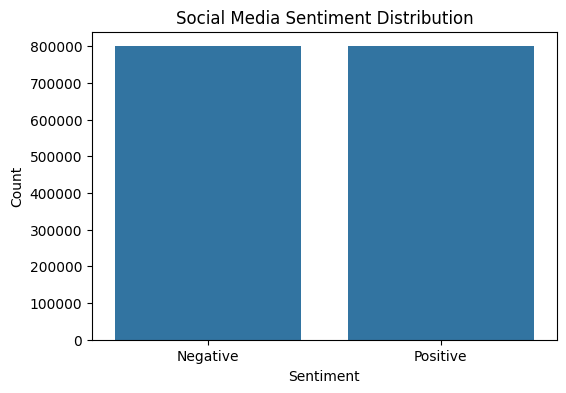

In [10]:
# Class Distribution
print(df_social['target'].value_counts())

label_map = {0: "Negative",  4: "Positive"}
df_social['sentiment_label'] = df_social['target'].map(label_map)

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment_label', data=df_social)
plt.title("Social Media Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [11]:
rt_start = df_social["text"].astype(str).str.match(r"^RT\s", case=False, na=False)
rt_anywhere = df_social["text"].astype(str).str.contains(r"\bRT\b", case=False, na=False)

print("Tweets starting with RT:", rt_start.sum())
print("Tweets containing RT anywhere:", rt_anywhere.sum())

display(df_social.loc[rt_start, ["text"]].head(10))

Tweets starting with RT: 125
Tweets containing RT anywhere: 458


,text
971,rt @KimKardashian Khloe just got fired from th...
17575,Rt @LilTanLines I know I'm Special... hahaha B...
19645,"rt @abisignorelli #f1 oh no, felipe baby"
45555,Rt @ColinCurtisKS @kellyjay7 is not going to I...
98347,Rt @DeltaKnowledge: My Twitter stream is so qu...
118646,rt @xinit lol Celebrity death from swine flu c...
132678,rt @skydiver How to tell it's a Monday? I pack...
156388,rt @johnesmithwick I miss the Hideout ~ is i...
164343,rt : @LiLi214 ughhhh got fuckin pulled over fo...
190095,Rt @prolife4life A botched abortion in a mothe...


# Cleaned Sentiment140 Dataset

In [12]:
cleanSentiment140_path = "../data/cleaned_sentiment140.csv"

df_cleanSocial = pd.read_csv(cleanSentiment140_path)
df_cleanSocial

,sentiment_label,clean_text
0,Negative,awww that s a bummer you shoulda got david car...
1,Negative,is upset that he can t update his facebook by ...
2,Negative,i dived many times for the ball managed to sav...
3,Negative,my whole body feels itchy and like its on fire
4,Negative,no it s not behaving at all i m mad why am i h...
...,...,...
1596397,Positive,just woke up having no school is the best feel...
1596398,Positive,thewdb com very cool to hear old walt interviews
1596399,Positive,are you ready for your mojo makeover ask me fo...
1596400,Positive,happy 38th birthday to my boo of alll time tup...


In [14]:
df_cleanSocial.shape

(1596402, 2)

In [15]:
df_cleanSocial.info

<bound method DataFrame.info of         sentiment_label                                         clean_text
0              Negative  awww that s a bummer you shoulda got david car...
1              Negative  is upset that he can t update his facebook by ...
2              Negative  i dived many times for the ball managed to sav...
3              Negative     my whole body feels itchy and like its on fire
4              Negative  no it s not behaving at all i m mad why am i h...
...                 ...                                                ...
1596397        Positive  just woke up having no school is the best feel...
1596398        Positive   thewdb com very cool to hear old walt interviews
1596399        Positive  are you ready for your mojo makeover ask me fo...
1596400        Positive  happy 38th birthday to my boo of alll time tup...
1596401        Positive                               happy charitytuesday

[1596402 rows x 2 columns]>

In [16]:
df_cleanSocial.isnull().sum()

sentiment_label    0
clean_text         0
dtype: int64

In [22]:
df_cleanSocial['sentiment_label'].unique()

<StringArray>
['Negative', 'Positive']
Length: 2, dtype: str

sentiment_label
Negative    798340
Positive    798062
Name: count, dtype: int64


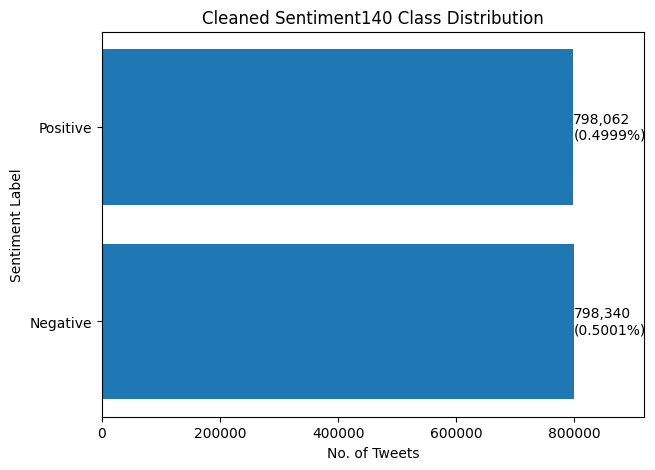

In [39]:
# Class Distribution
label_counts = df_cleanSocial['sentiment_label'].value_counts().sort_index()
total = label_counts.sum()
print(label_counts)

plt.figure(figsize=(7,5))
bars = plt.barh(label_counts.index, label_counts.values)

plt.title("Cleaned Sentiment140 Class Distribution")
plt.xlabel("No. of Tweets")
plt.ylabel("Sentiment Label")

plt.xlim(0, label_counts.max() * 1.15)
for bar, count in zip(bars, label_counts.values):
    plt.text(
        bar.get_width() + label_counts.max() * 0.00003,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}\n({count/total:.4f}%)",
        va="center",
    )

plt.show()